# Trabajo Práctico Final IIA: Predicción de penales mediante Transfer Learning

**Integrantes:** López Agustín y Lynn Bosio Baltazar

**Problema:** a partir de una imagen del impacto pie-pelota, predecir dónde va el tiro.

Tres modelos independientes:

Experimento | Salida |
------------|--------|
Regresión | `(x, y)` |
Clasificación L/C/R | izq / centro / der |
Clasificación L/R | izq / der |

In [1]:
from pathlib import Path
import ctypes
import gc
import os
import re
import sys

# CUDA (wheels nvidia-*): precargar por si el kernel no exportó LD_LIBRARY_PATH.
_sp = Path(sys.prefix) / 'lib' / f'python{sys.version_info.major}.{sys.version_info.minor}' / 'site-packages'
_n = 0
for _pkg in (
    'cuda_runtime', 'nvjitlink', 'cublas', 'cudnn', 'cufft', 'curand',
    'cusolver', 'cusparse', 'cuda_nvrtc', 'cuda_cupti', 'nccl',
):
    for _so in sorted((_sp / 'nvidia' / _pkg / 'lib').glob('lib*.so*')):
        try:
            ctypes.CDLL(str(_so), mode=ctypes.RTLD_GLOBAL)
            _n += 1
        except OSError:
            pass

if os.environ.get('CUDA_VISIBLE_DEVICES', None) == '':
    os.environ.pop('CUDA_VISIBLE_DEVICES', None)

if 'tensorflow' in sys.modules:
    print('AVISO: tensorflow ya estaba importado en este kernel.')
    print('Reiniciá el kernel (Restart) y volvé a correr esta celda.')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from PIL import Image
from scipy.stats import binomtest
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import StratifiedGroupKFold, train_test_split
from tensorflow.keras import layers, models
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input

DATASET = Path('dataset')
IMG_SIZE = 299  # tamaño de entrada de InceptionV3
BATCH = 12

gpus = tf.config.list_physical_devices('GPU')
print('Python:', sys.executable)
print('CUDA libs precargadas:', _n)
print('GPU:', gpus)
if not gpus:
    raise SystemExit(
        'Sin GPU. Elegí kernel "Python (TP_Final GPU)", Restart Kernel, y re-ejecutá esta celda.'
    )


I0000 00:00:1785454170.064838  799393 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785454170.969266  799393 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785454172.664942  799393 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Python: /home/agustin/IA/TP_Final/.venv/bin/python.bin
CUDA libs precargadas: 31
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Dataset

Las imágenes base siguen la convención:

`penal_<competencia>_<año>_<equipo1>_<equipo2>_<orden>.png`

Los frames extra del mismo disparo se nombran agregando `_1`, `_2`, ... (ej. `..._01_1.png`).

Las etiquetas `(x, y)` son dónde la pelota cruza la línea de gol:

- `(0, 0)`: intersección del palo izquierdo con la línea de meta (vista desde la cámara)
- `(1, 1)`: vértice superior derecho del arco

La columna `arquero` (con valores `L`, `CL`, `CR`, `R`) indica hacia qué lado se tiró el arquero. Es el baseline humano: comparamos las predicciones del modelo con las decisiones que efectivamente toman los arqueros 


Penales: 449 - frames: 1414

Tiro L/C/R:
izquierda    211
derecha      183
centro        55

Aciertos del arquero L/C/R: 43.2%
Aciertos del arquero L/R:   49.7%


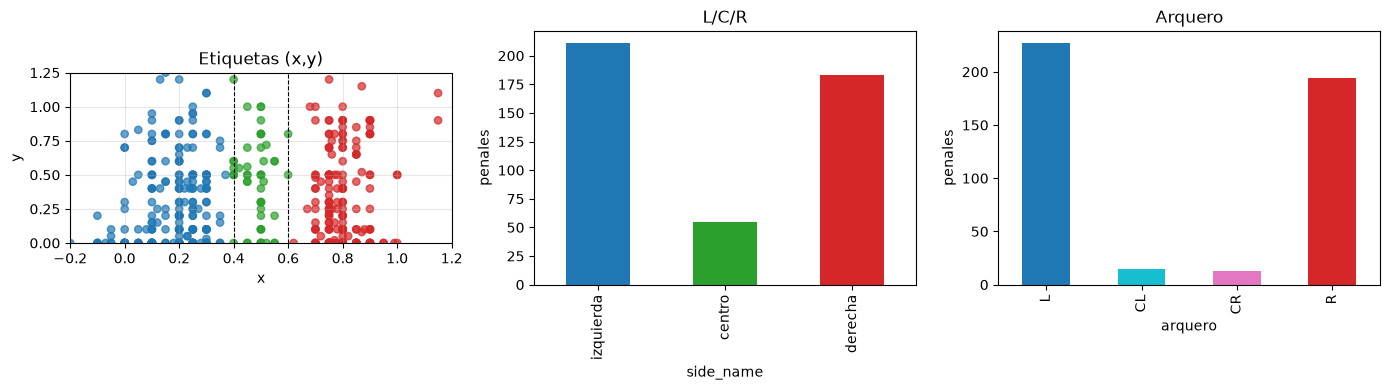

In [2]:
def x_to_side(x):
    if x < 0.4: return 0
    if x <= 0.6: return 1
    return 2

SIDE_NAMES = {0: 'izquierda', 1: 'centro', 2: 'derecha'}
BINARY_NAMES = {0: 'izquierda', 1: 'derecha'}

# Mapeo del lado del arquero a las etiquetas del modelo
ARQUERO_TO_LCR = {'L': 0, 'CL': 1, 'CR': 1, 'R': 2}
ARQUERO_TO_LR = {'L': 0, 'CL': 0, 'CR': 1, 'R': 1}

def cargar_labels(csv_path, img_dir):
    img_dir = Path(img_dir)
    raw = pd.read_csv(csv_path)
    rows = []
    for _, r in raw.iterrows():
        base = str(r['penal'])
        stem = Path(base).stem
        names = [base]
        for p in sorted(img_dir.glob(f'{stem}_*.png')):
            # Nombre tipo ..._1.png, ..._2.png (frames extra)
            if re.compile(r'^(.+)_([1-9]\d*)\.png$', re.IGNORECASE).match(p.name):
                names.append(p.name)
        for name in names:
            rows.append({
                'penal': name,
                'penal_id': base,
                'path': str(img_dir / name),
                'x': float(r['x']),
                'y': float(r['y']),
                'arquero': r['arquero'],
            })
    df = pd.DataFrame(rows)
    df['side'] = df['x'].map(x_to_side)
    df['side_name'] = df['side'].map(SIDE_NAMES)
    df['binary'] = (df['x'] >= 0.5).astype(np.int32)  # 0=izq, 1=der
    df['arquero_lcr'] = df['arquero'].map(ARQUERO_TO_LCR)
    df['arquero_lr'] = df['arquero'].map(ARQUERO_TO_LR)
    return df


def style_goal_axes(ax):
    ax.set_xlim(-0.2, 1.2); ax.set_ylim(0, 1.25)
    ax.set_aspect(0.5, adjustable='box')
    ax.set_xlabel('x'); ax.set_ylabel('y')


df = cargar_labels(DATASET / 'labels.csv', DATASET / 'img')
df_penals = df.drop_duplicates('penal_id')  # una fila por disparo (para stats)

print(f'Penales: {len(df_penals)} - frames: {len(df)}\n')
print('Tiro L/C/R:')
print(df_penals['side_name'].value_counts().rename_axis(None).to_string())
print(f"\nAciertos del arquero L/C/R: {(df_penals['arquero_lcr'] == df_penals['side']).mean():.1%}")
print(f"Aciertos del arquero L/R:   {(df_penals['arquero_lr'] == df_penals['binary']).mean():.1%}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = df_penals['side'].map({0: 'tab:blue', 1: 'tab:green', 2: 'tab:red'})
axes[0].scatter(df_penals['x'], df_penals['y'], c=colors, alpha=0.7, s=28)
axes[0].axvline(0.4, ls='--', c='k', lw=0.8); axes[0].axvline(0.6, ls='--', c='k', lw=0.8)
axes[0].set_title('Etiquetas (x,y)'); style_goal_axes(axes[0]); axes[0].grid(True, alpha=0.3)
df_penals['side_name'].value_counts().reindex(['izquierda', 'centro', 'derecha']).plot(
    kind='bar', ax=axes[1], color=['tab:blue', 'tab:green', 'tab:red'])
axes[1].set_title('L/C/R'); axes[1].set_ylabel('penales')
df_penals['arquero'].value_counts().reindex(['L', 'CL', 'CR', 'R']).plot(
    kind='bar', ax=axes[2], color=['tab:blue', 'tab:cyan', 'tab:pink', 'tab:red'])
axes[2].set_title('Arquero'); axes[2].set_ylabel('penales')
plt.tight_layout(); plt.show()


## 2. Split del dataset en train/val/test y k-fold

1. Tomamos el dataframe de penales sin los frames extra, luego separamos el 15% de los datos como test (estratificado por L/C/R para mantener siempre las proporciones).

2. Con esos `penal_id`, armamos `df_dev` y `df_test` filtrando el dataframe completo: así cada split lleva todos los frames del tiro (base + extras).

3. Realizamos el k-fold con k = 5 sobre nuestro dataframe de train.


In [3]:
ids_dev, ids_test = train_test_split(
    df_penals['penal_id'], test_size=0.15, stratify=df_penals['side'], random_state=42
)

df_dev = df[df['penal_id'].isin(ids_dev)]
df_test = df[df['penal_id'].isin(ids_test)]

N_FOLDS = 5
kfold = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
folds = list(kfold.split(df_dev, df_dev['side'], groups=df_dev['penal_id']))

print(f'dev:  {df_dev["penal_id"].nunique()} penales / {len(df_dev)} frames')
print(f'test: {df_test["penal_id"].nunique()} penales / {len(df_test)} frames')

for i, (tr, va) in enumerate(folds, 1):
    n_tr = df_dev.iloc[tr]['penal_id'].nunique()
    n_va = df_dev.iloc[va]['penal_id'].nunique()
    print(f'  fold {i}: train {n_tr} penales / {len(tr)} frames | val {n_va} penales / {len(va)} frames')



dev:  381 penales / 1198 frames
test: 68 penales / 216 frames
  fold 1: train 305 penales / 958 frames | val 76 penales / 240 frames
  fold 2: train 305 penales / 958 frames | val 76 penales / 240 frames
  fold 3: train 305 penales / 959 frames | val 76 penales / 239 frames
  fold 4: train 305 penales / 959 frames | val 76 penales / 239 frames
  fold 5: train 304 penales / 958 frames | val 77 penales / 240 frames


## 3. Carga de datos, construcción del modelo y análisis de resultados

En esta sección se cargan las imágenes como arrays, construimos InceptionV3 con su cabeza, y definimos helpers de evaluación (métricas por penal, comparación vs arquero).

El único augmentation geométrico es el flip horizontal, aplicado solo al train de cada fold: se espeja la imagen, se corrige `x = 1 − x` y se invierten las etiquetas L y R.

In [11]:
def load_image(path):
    with Image.open(path) as im:
        return np.asarray(im.convert('RGB').resize((IMG_SIZE, IMG_SIZE)))


def load_split(frame):
    X = np.stack([load_image(p) for p in frame['path']])
    y_xy = frame[['x', 'y']].to_numpy(np.float32)
    y_side = frame['side'].to_numpy(np.int32)
    y_bin = frame['binary'].to_numpy(np.int32)
    penal_ids = frame['penal_id'].to_numpy()
    gk_lcr = frame['arquero_lcr'].to_numpy(np.int32)
    gk_lr = frame['arquero_lr'].to_numpy(np.int32)
    return X, y_xy, y_side, y_bin, penal_ids, gk_lcr, gk_lr


def add_flips(X, y_xy, y_side, y_bin):
    Xf = X[:, :, ::-1].copy()
    yf = y_xy.copy()
    yf[:, 0] = 1.0 - yf[:, 0]
    sf = np.array([{0: 2, 1: 1, 2: 0}[int(s)] for s in y_side])
    bf = 1 - y_bin
    return (np.concatenate([X, Xf]), np.concatenate([y_xy, yf]),
            np.concatenate([y_side, sf]), np.concatenate([y_bin, bf]))


def make_train_ds(X, y):
    ds = tf.data.Dataset.from_tensor_slices((X, y)).shuffle(len(X), seed=42)
    return ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)


def make_eval_ds(X, y):
    return tf.data.Dataset.from_tensor_slices(
        (X.astype(np.float32), y)).batch(BATCH).prefetch(tf.data.AUTOTUNE)


def build_model(n_out, activation=None):
    base = InceptionV3(include_top=False, pooling='avg')
    base.trainable = False
    inp = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = layers.RandomBrightness(0.15)(inp)
    x = layers.RandomContrast(0.15)(x)
    x = layers.Lambda(preprocess_input)(x)
    x = base(x, training=False)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(64, activation='relu')(x)
    return models.Model(inp, layers.Dense(n_out, activation=activation)(x))


def preds_by_penal_from_proba(penal_ids, y_true, proba, gk_labels):
    order, idx = np.unique(penal_ids, return_index=True)
    order = penal_ids[np.sort(idx)]
    y_p, pred_p, gk_p = [], [], []
    for pid in order:
        m = penal_ids == pid
        pred_p.append(int(np.argmax(proba[m].mean(axis=0))))
        y_p.append(int(y_true[m][0]))
        gk_p.append(int(gk_labels[m][0]))
    return np.asarray(y_p), np.asarray(pred_p), np.asarray(gk_p)


def compare_model_vs_arquero(y_true, y_pred, y_gk, task_name, plot=True):
    m_ok = y_pred == y_true
    g_ok = y_gk == y_true
    both = int(np.sum(m_ok & g_ok))
    only_model = int(np.sum(m_ok & ~g_ok))
    only_gk = int(np.sum(~m_ok & g_ok))
    neither = int(np.sum(~m_ok & ~g_ok))
    n = len(y_true)
    acc_m, acc_g = float(m_ok.mean()), float(g_ok.mean())
    n_disc = only_model + only_gk
    p_mcn = 1.0 if n_disc == 0 else float(binomtest(only_model, n=n_disc, p=0.5).pvalue)

    print(f'\n=== {task_name}: modelo vs arquero (n={n} penales) ===')
    print(f'  Accuracy modelo:  {acc_m:.1%}  ({int(m_ok.sum())}/{n})')
    print(f'  Accuracy arquero: {acc_g:.1%}  ({int(g_ok.sum())}/{n})')
    print(f'  Δ (modelo−arquero): {acc_m - acc_g:+.1%}')
    print(f'  ambos OK={both} | solo modelo={only_model} | solo arquero={only_gk} | ambos fail={neither}')
    print(f'  McNemar p={p_mcn:.4f}  '
          f'({"significativo α=0.05" if p_mcn < 0.05 else "no significativo α=0.05"})')

    table = np.array([[both, only_model], [only_gk, neither]])
    if plot:
        fig, ax = plt.subplots(figsize=(4.8, 4))
        im = ax.imshow(table, cmap='YlOrBr')
        ax.set_xticks([0, 1], ['Arqu. OK', 'Arqu. fail'])
        ax.set_yticks([0, 1], ['Modelo OK', 'Modelo fail'])
        ax.set_title(f'{task_name}\nMcNemar p={p_mcn:.3f}')
        for i in range(2):
            for j in range(2):
                ax.text(j, i, int(table[i, j]), ha='center', va='center', fontsize=14)
        fig.colorbar(im, ax=ax, fraction=0.046)
        fig.tight_layout(); plt.show()

    return {
        'acc_model': acc_m,
        'acc_gk': acc_g,
        'mcnemar_p': p_mcn,
        'both': both,
        'only_model': only_model,
        'only_gk': only_gk,
        'neither': neither,
    }


## 4. Entrenamiento sobre los 3 modelos

Tres entrenamientos independientes sobre los mismos folds. En cada fold primero se entrena solo la cabeza (backbone congelado y LR alto) y después se hace fine-tuning de las últimas capas (LR bajo), con EarlyStopping sobre `val_loss`.

Se guardan predicciones OOF en `dev` y se acumulan las del test para el ensemble final. Las curvas muestran media ± desvío estándar entre folds de train, val y test.


In [5]:
EPOCHS_HEAD, EPOCHS_FT = 16, 40
FT_UNFREEZE = 40
tf.keras.utils.set_random_seed(5)

X_dev, y_dev, s_dev, b_dev, pid_dev, gk_lcr_dev, gk_lr_dev = load_split(df_dev)
X_te, y_te, s_te, b_te, pid_te, gk_lcr_te, gk_lr_te = load_split(df_test)
print(f'dev {len(X_dev)} frames | test {len(X_te)} frames')


def concat_histories(h1, h2):
    keys = list(dict.fromkeys([*h1.keys(), *h2.keys()]))
    return {k: list(h1.get(k, [])) + list(h2.get(k, [])) for k in keys}


def hist_for_plots(h):
    out = {}
    for k, v in h.items():
        if k.startswith('val_'):
            out[k] = list(map(float, v))
        elif k in ('learning_rate', 'lr'):
            continue
        else:
            out[f'train_{k}'] = list(map(float, v))
    return out


def fit_phases(model, X_train, y_train, X_val, y_val, X_test, y_test, loss, metrics):
    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=0
    )
    # Test hold-out por época
    test_hist = {}
    X_te_f = X_test.astype(np.float32)

    def on_test_epoch_end(epoch, logs=None):
        out = model.evaluate(X_te_f, y_test, verbose=0, return_dict=True)
        for k, v in out.items():
            test_hist.setdefault(f'test_{k}', []).append(float(v))

    track_test = tf.keras.callbacks.LambdaCallback(on_epoch_end=on_test_epoch_end)
    train_ds = make_train_ds(X_train, y_train)
    val_ds = make_eval_ds(X_val, y_val)

    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss=loss, metrics=metrics)
    h1 = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_HEAD,
                   callbacks=[reduce_lr, track_test], verbose=1).history

    base = model.get_layer('inception_v3')
    base.trainable = True
    for layer in base.layers[:-FT_UNFREEZE]:
        layer.trainable = False

    early = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=8, restore_best_weights=True, verbose=1
    )
    model.compile(optimizer=tf.keras.optimizers.Adam(3e-5), loss=loss, metrics=metrics)
    h2 = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_FT,
                   callbacks=[reduce_lr, early, track_test], verbose=1).history

    hist = hist_for_plots(concat_histories(h1, h2))
    hist.update(test_hist)
    return hist


def pad_histories(histories, key):
    lens = [len(h[key]) for h in histories]
    m = max(lens)
    arr = np.full((len(histories), m), np.nan, dtype=float)
    for i, h in enumerate(histories):
        arr[i, :len(h[key])] = h[key]
    return arr


def plot_cv_curves(histories, keys, titles, name):
    fig, axes = plt.subplots(1, len(keys), figsize=(5.2 * len(keys), 3.8))
    if len(keys) == 1:
        axes = [axes]
    styles = [('train', 'tab:blue'), ('val', 'tab:orange'), ('test', 'tab:green')]
    for ax, key, title in zip(axes, keys, titles):
        for split, color in styles:
            mat = pad_histories(histories, f'{split}_{key}')
            mean, std = np.nanmean(mat, axis=0), np.nanstd(mat, axis=0)
            xs = np.arange(1, len(mean) + 1)
            ax.plot(xs, mean, color=color, label=split, lw=2)
            ax.fill_between(xs, mean - std, mean + std, color=color, alpha=0.2)
        ax.axvline(EPOCHS_HEAD + 0.5, color='k', ls='--', alpha=0.4, label='inicio FT')
        ax.set_title(f'{name} — {title}'); ax.set_xlabel('Época')
        ax.grid(True, alpha=0.3); ax.legend()
    fig.tight_layout(); plt.show()


def get_fold_arrays(tr_idx, va_idx):
    """Train/val de un fold + flips solo en train."""
    X_tr, y_tr = X_dev[tr_idx], y_dev[tr_idx]
    s_tr, b_tr = s_dev[tr_idx], b_dev[tr_idx]
    X_va, y_va = X_dev[va_idx], y_dev[va_idx]
    s_va, b_va = s_dev[va_idx], b_dev[va_idx]
    X_tr, y_tr, s_tr, b_tr = add_flips(X_tr, y_tr, s_tr, b_tr)
    return X_tr, y_tr, s_tr, b_tr, X_va, y_va, s_va, b_va


dev 1198 frames | test 216 frames


In [6]:
# ========== A) Regresión — 5-fold ==========
oof_xy = np.zeros((len(X_dev), 2))
test_xy_sum = np.zeros((len(X_te), 2))
hist_reg = []
fold_reg = []

print('=== A) Regresión ===')
for fold_i, (tr_idx, va_idx) in enumerate(folds, 1):
    print(f'\n--- A fold {fold_i}/{N_FOLDS} ---')
    X_tr, y_tr, s_tr, b_tr, X_va, y_va, s_va, b_va = get_fold_arrays(tr_idx, va_idx)
    print(f'train {len(X_tr)} (con flip) | val {len(X_va)}')

    tf.keras.backend.clear_session()
    reg = build_model(2, activation=None)
    hist_reg.append(fit_phases(
        reg, X_tr, y_tr, X_va, y_va, X_te, y_te,
        loss=tf.keras.losses.Huber(0.25),
        metrics=[tf.keras.metrics.MeanAbsoluteError(name='mae')],
    ))
    pred_va = reg.predict(X_va.astype(np.float32), verbose=0)
    oof_xy[va_idx] = pred_va
    test_xy_sum += reg.predict(X_te.astype(np.float32), verbose=0)
    side_va = np.array([x_to_side(float(v)) for v in pred_va[:, 0]])
    mae_f = float(np.mean(np.abs(pred_va - y_va)))
    side_f = float(np.mean(side_va == s_va))
    stdx_f = float(pred_va[:, 0].std())
    fold_reg.append({'fold': fold_i, 'mae': mae_f, 'reg_side': side_f, 'std_x': stdx_f})
    print(f'fold {fold_i}: MAE={mae_f:.3f} std_x={stdx_f:.3f} reg→lado={side_f:.1%}')
    del reg; gc.collect()

test_xy = (test_xy_sum / N_FOLDS).astype(np.float32)
fm_reg = pd.DataFrame(fold_reg)
print('\nA) Resumen folds:')
print(fm_reg.to_string(index=False))
print(fm_reg[['mae', 'reg_side', 'std_x']].agg(['mean', 'std']).round(4))


=== A) Regresión ===

--- A fold 1/5 ---
train 1916 (con flip) | val 240


I0000 00:00:1785454181.095662  799393 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 8253 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


Epoch 1/16


I0000 00:00:1785454189.604707  799802 service.cc:153] XLA service 0x7fe228074fc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1785454189.604722  799802 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3060, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.25.0)
I0000 00:00:1785454190.078682  799802 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1785454191.538150  799802 cuda_dnn.cc:461] Loaded cuDNN version 92500
I0000 00:00:1785454191.678355  799802 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_12583__.210


  2/160 ━━━━━━━━━━━━━━━━━━━━ 10s 65ms/step - loss: 0.1066 - mae: 0.5307 

...

160/160 ━━━━━━━━━━━━━━━━━━━━ 29s 134ms/step - loss: 0.0542 - mae: 0.3257 - val_loss: 0.0481 - val_mae: 0.3050 - learning_rate: 0.0010
Epoch 2/16
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - loss: 0.0446 - mae: 0.2865 - val_loss: 0.0497 - val_mae: 0.3113 - learning_rate: 0.0010
Epoch 3/16
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - loss: 0.0433 - mae: 0.2809 - val_loss: 0.0499 - val_mae: 0.3117 - learning_rate: 0.0010
Epoch 4/16
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - loss: 0.0420 - mae: 0.2742 - val_loss: 0.0512 - val_mae: 0.3162 - learning_rate: 0.0010
Epoch 5/16
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - loss: 0.0413 - mae: 0.2713 - val_loss: 0.0495 - val_mae: 0.3104 - learning_rate: 5.0000e-04
Epoch 6/16
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - loss: 0.0401 - mae: 0.2662 - val_loss: 0.0502 - val_mae: 0.3130 - learning_rate: 5.0000e-04
Epoch 7/16
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - loss: 0.0393 - mae: 0.2620 - val_loss: 0.0511 - val_mae: 0.3163 - learning_rate: 5.0000e

I0000 00:00:1785455430.992676  799804 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_312616__.260


159/160 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0386 - mae: 0.2619

I0000 00:00:1785455442.589792  799804 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_312616__.260


160/160 ━━━━━━━━━━━━━━━━━━━━ 34s 147ms/step - loss: 0.0380 - mae: 0.2581 - val_loss: 0.0485 - val_mae: 0.3024 - learning_rate: 3.0000e-05
Epoch 2/40
160/160 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - loss: 0.0320 - mae: 0.2276 - val_loss: 0.0499 - val_mae: 0.3090 - learning_rate: 3.0000e-05
Epoch 3/40
160/160 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - loss: 0.0281 - mae: 0.2092 - val_loss: 0.0505 - val_mae: 0.3108 - learning_rate: 3.0000e-05
Epoch 4/40
160/160 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - loss: 0.0247 - mae: 0.1922 - val_loss: 0.0515 - val_mae: 0.3140 - learning_rate: 1.5000e-05
Epoch 5/40
160/160 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - loss: 0.0235 - mae: 0.1863 - val_loss: 0.0501 - val_mae: 0.3059 - learning_rate: 1.5000e-05
Epoch 6/40
160/160 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - loss: 0.0222 - mae: 0.1789 - val_loss: 0.0513 - val_mae: 0.3138 - learning_rate: 1.5000e-05
Epoch 7/40
160/160 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - loss: 0.0208 - mae: 0.1726 - val_loss: 0.0510 - val_mae: 0.3122 - learni

In [7]:
# ========== B) Clasificación L/C/R — 5-fold ==========
oof_lcr = np.zeros((len(X_dev), 3))
test_lcr_sum = np.zeros((len(X_te), 3))
hist_lcr = []
fold_lcr = []

print('=== B) Clasificación L/C/R ===')
for fold_i, (tr_idx, va_idx) in enumerate(folds, 1):
    print(f'\n--- B fold {fold_i}/{N_FOLDS} ---')
    X_tr, y_tr, s_tr, b_tr, X_va, y_va, s_va, b_va = get_fold_arrays(tr_idx, va_idx)
    print(f'train {len(X_tr)} (con flip) | val {len(X_va)}')

    tf.keras.backend.clear_session()
    clf = build_model(3, activation='softmax')
    hist_lcr.append(fit_phases(
        clf, X_tr, s_tr, X_va, s_va, X_te, s_te,
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name='acc')],
    ))
    proba_va = clf.predict(X_va.astype(np.float32), verbose=0)
    oof_lcr[va_idx] = proba_va
    test_lcr_sum += clf.predict(X_te.astype(np.float32), verbose=0)
    acc_f = float(np.mean(np.argmax(proba_va, axis=1) == s_va))
    fold_lcr.append({'fold': fold_i, 'acc_lcr': acc_f})
    print(f'fold {fold_i}: L/C/R acc={acc_f:.1%}')
    del clf; gc.collect()

test_lcr = (test_lcr_sum / N_FOLDS).astype(np.float32)
fm_lcr = pd.DataFrame(fold_lcr)
print('\nB) Resumen folds:')
print(fm_lcr.to_string(index=False))
print(fm_lcr[['acc_lcr']].agg(['mean', 'std']).round(4))


=== B) Clasificación L/C/R ===

--- B fold 1/5 ---
train 1916 (con flip) | val 240
Epoch 1/16


I0000 00:00:1785455532.117139  799803 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_344877__.215


159/160 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - acc: 0.4307 - loss: 1.0291

I0000 00:00:1785455541.752273  799804 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_344877__.215


160/160 ━━━━━━━━━━━━━━━━━━━━ 30s 136ms/step - acc: 0.4295 - loss: 0.9973 - val_acc: 0.4625 - val_loss: 0.9751 - learning_rate: 0.0010
Epoch 2/16
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - acc: 0.4332 - loss: 0.9475 - val_acc: 0.4417 - val_loss: 0.9715 - learning_rate: 0.0010
Epoch 3/16
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - acc: 0.4562 - loss: 0.9238 - val_acc: 0.4833 - val_loss: 0.9896 - learning_rate: 0.0010
Epoch 4/16
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - acc: 0.4405 - loss: 0.9028 - val_acc: 0.4583 - val_loss: 1.0161 - learning_rate: 0.0010
Epoch 5/16
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - acc: 0.4593 - loss: 0.8823 - val_acc: 0.4833 - val_loss: 1.0046 - learning_rate: 0.0010
Epoch 6/16
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - acc: 0.4969 - loss: 0.8526 - val_acc: 0.4750 - val_loss: 1.0102 - learning_rate: 5.0000e-04
Epoch 7/16
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - acc: 0.5026 - loss: 0.8455 - val_acc: 0.5125 - val_loss: 1.0268 - learning_rate: 5.0000e-04


...

160/160 ━━━━━━━━━━━━━━━━━━━━ 31s 143ms/step - acc: 0.4222 - loss: 1.0074 - val_acc: 0.4667 - val_loss: 0.9813 - learning_rate: 0.0010
Epoch 2/16
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - acc: 0.4363 - loss: 0.9570 - val_acc: 0.4500 - val_loss: 0.9962 - learning_rate: 0.0010
Epoch 3/16
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - acc: 0.4415 - loss: 0.9229 - val_acc: 0.4125 - val_loss: 1.0471 - learning_rate: 0.0010
Epoch 4/16
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - acc: 0.4614 - loss: 0.9032 - val_acc: 0.4167 - val_loss: 1.0109 - learning_rate: 0.0010
Epoch 5/16
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - acc: 0.4875 - loss: 0.8671 - val_acc: 0.4000 - val_loss: 1.0214 - learning_rate: 5.0000e-04
Epoch 6/16
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - acc: 0.5000 - loss: 0.8583 - val_acc: 0.3833 - val_loss: 1.0333 - learning_rate: 5.0000e-04
Epoch 7/16
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - acc: 0.4974 - loss: 0.8503 - val_acc: 0.4208 - val_loss: 1.0511 - learning_rate: 5.0000e

I0000 00:00:1785456554.917771  799804 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_624608__.265


158/160 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - acc: 0.5145 - loss: 0.8368

I0000 00:00:1785456566.903167  799800 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_624608__.265


160/160 ━━━━━━━━━━━━━━━━━━━━ 36s 154ms/step - acc: 0.5164 - loss: 0.8100 - val_acc: 0.4125 - val_loss: 1.1422 - learning_rate: 3.0000e-05
Epoch 2/40
160/160 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - acc: 0.5778 - loss: 0.6906 - val_acc: 0.4083 - val_loss: 1.2608 - learning_rate: 3.0000e-05
Epoch 3/40
160/160 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - acc: 0.5992 - loss: 0.6533 - val_acc: 0.4750 - val_loss: 1.2527 - learning_rate: 3.0000e-05
Epoch 4/40
160/160 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - acc: 0.6597 - loss: 0.6233 - val_acc: 0.4875 - val_loss: 1.2929 - learning_rate: 1.5000e-05
Epoch 5/40
160/160 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - acc: 0.6722 - loss: 0.6170 - val_acc: 0.4500 - val_loss: 1.3429 - learning_rate: 1.5000e-05
Epoch 6/40
160/160 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - acc: 0.6728 - loss: 0.6049 - val_acc: 0.4500 - val_loss: 1.3628 - learning_rate: 1.5000e-05
Epoch 7/40
160/160 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - acc: 0.7030 - loss: 0.5981 - val_acc: 0.4792 - val_loss: 1.3373 - learni

In [8]:
# ========== C) Clasificación L/R — 5-fold ==========
oof_lr = np.zeros((len(X_dev), 2))
test_lr_sum = np.zeros((len(X_te), 2))
hist_lr = []
fold_lr = []

print('=== C) Clasificación L/R ===')
for fold_i, (tr_idx, va_idx) in enumerate(folds, 1):
    print(f'\n--- C fold {fold_i}/{N_FOLDS} ---')
    X_tr, y_tr, s_tr, b_tr, X_va, y_va, s_va, b_va = get_fold_arrays(tr_idx, va_idx)
    print(f'train {len(X_tr)} (con flip) | val {len(X_va)}')

    tf.keras.backend.clear_session()
    clf_lr = build_model(2, activation='softmax')
    hist_lr.append(fit_phases(
        clf_lr, X_tr, b_tr, X_va, b_va, X_te, b_te,
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name='acc')],
    ))
    proba_va = clf_lr.predict(X_va.astype(np.float32), verbose=0)
    oof_lr[va_idx] = proba_va
    test_lr_sum += clf_lr.predict(X_te.astype(np.float32), verbose=0)
    acc_f = float(np.mean(np.argmax(proba_va, axis=1) == b_va))
    fold_lr.append({'fold': fold_i, 'acc_lr': acc_f})
    print(f'fold {fold_i}: L/R acc={acc_f:.1%}')
    del clf_lr; gc.collect()

test_lr = (test_lr_sum / N_FOLDS).astype(np.float32)    
fm_lr = pd.DataFrame(fold_lr)
print('\nC) Resumen folds:')
print(fm_lr.to_string(index=False))
print(fm_lr[['acc_lr']].agg(['mean', 'std']).round(4))


=== C) Clasificación L/R ===

--- C fold 1/5 ---
train 1916 (con flip) | val 240
Epoch 1/16


I0000 00:00:1785456657.940473  799804 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_656880__.215


159/160 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - acc: 0.5030 - loss: 0.7821

I0000 00:00:1785456667.583158  799802 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_656880__.215


160/160 ━━━━━━━━━━━━━━━━━━━━ 30s 136ms/step - acc: 0.4906 - loss: 0.7387 - val_acc: 0.5958 - val_loss: 0.6775 - learning_rate: 0.0010
Epoch 2/16
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - acc: 0.4802 - loss: 0.7062 - val_acc: 0.4958 - val_loss: 0.6933 - learning_rate: 0.0010
Epoch 3/16
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - acc: 0.4885 - loss: 0.6935 - val_acc: 0.5125 - val_loss: 0.6930 - learning_rate: 0.0010
Epoch 4/16
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - acc: 0.4849 - loss: 0.6933 - val_acc: 0.5125 - val_loss: 0.6934 - learning_rate: 0.0010
Epoch 5/16
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - acc: 0.4896 - loss: 0.6941 - val_acc: 0.4875 - val_loss: 0.6932 - learning_rate: 5.0000e-04
Epoch 6/16
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - acc: 0.4890 - loss: 0.6932 - val_acc: 0.4875 - val_loss: 0.6932 - learning_rate: 5.0000e-04
Epoch 7/16
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - acc: 0.4922 - loss: 0.6933 - val_acc: 0.4875 - val_loss: 0.6932 - learning_rate: 5.0000e

...

160/160 ━━━━━━━━━━━━━━━━━━━━ 30s 134ms/step - acc: 0.4875 - loss: 0.7337 - val_acc: 0.4625 - val_loss: 0.6993 - learning_rate: 0.0010
Epoch 2/16
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - acc: 0.4828 - loss: 0.7046 - val_acc: 0.5042 - val_loss: 0.6907 - learning_rate: 0.0010
Epoch 3/16
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - acc: 0.5084 - loss: 0.6926 - val_acc: 0.5000 - val_loss: 0.6936 - learning_rate: 0.0010
Epoch 4/16
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - acc: 0.4979 - loss: 0.6933 - val_acc: 0.5000 - val_loss: 0.6932 - learning_rate: 0.0010
Epoch 5/16
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - acc: 0.5047 - loss: 0.6938 - val_acc: 0.5000 - val_loss: 0.6932 - learning_rate: 0.0010
Epoch 6/16
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - acc: 0.5010 - loss: 0.6932 - val_acc: 0.5000 - val_loss: 0.6932 - learning_rate: 5.0000e-04
Epoch 7/16
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - acc: 0.4916 - loss: 0.6931 - val_acc: 0.5000 - val_loss: 0.6932 - learning_rate: 5.0000e-04


I0000 00:00:1785457839.410779  799800 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_970610__.265


159/160 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - acc: 0.5018 - loss: 0.6944

I0000 00:00:1785457851.156841  799802 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_970610__.265


160/160 ━━━━━━━━━━━━━━━━━━━━ 48s 229ms/step - acc: 0.4972 - loss: 0.6959 - val_acc: 0.5042 - val_loss: 0.6939 - learning_rate: 3.0000e-05
Epoch 2/40
160/160 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - acc: 0.5318 - loss: 0.6886 - val_acc: 0.4083 - val_loss: 0.6970 - learning_rate: 3.0000e-05
Epoch 3/40
160/160 ━━━━━━━━━━━━━━━━━━━━ 11s 70ms/step - acc: 0.5558 - loss: 0.6750 - val_acc: 0.5167 - val_loss: 0.7012 - learning_rate: 3.0000e-05
Epoch 4/40
160/160 ━━━━━━━━━━━━━━━━━━━━ 9s 56ms/step - acc: 0.6033 - loss: 0.6505 - val_acc: 0.5042 - val_loss: 0.6966 - learning_rate: 1.5000e-05
Epoch 5/40
160/160 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - acc: 0.6211 - loss: 0.6335 - val_acc: 0.5167 - val_loss: 0.6966 - learning_rate: 1.5000e-05
Epoch 6/40
160/160 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - acc: 0.6566 - loss: 0.6117 - val_acc: 0.4917 - val_loss: 0.6959 - learning_rate: 1.5000e-05
Epoch 7/40
160/160 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - acc: 0.6994 - loss: 0.5860 - val_acc: 0.5125 - val_loss: 0.7006 - learn

## 5. Resultados OOF (dev, por penal)

Predicciones *out-of-fold* sobre `dev`. El modelo predice **por frame**, como un tiro puede tener varios frames (base + extras), agregamos por `penal_id`: promediamos las predicciones de sus frames (coordenadas `(x,y)` o probabilidades) y recién ahí obtenemos **un valor / una clase por penal**.

**Frame vs penal.** A nivel frame, cada crop cuenta por igual: un penal con 3 frames pesa tres veces más que uno con 1, y frames del mismo tiro pueden discrepar (uno a izquierda, otro a derecha). A nivel penal, promediamos esas predicciones y decidimos una sola vez por disparo, entonces baja el ruido entre frames del mismo tiro y la métrica queda alineada con “¿acertamos el lado de este penal?”, comparable al arquero. En el test mostramos ambas vistas (barras por frame y por penal).

Las curvas de aprendizaje muestran media ± desvío estándar entre los 5 folds.

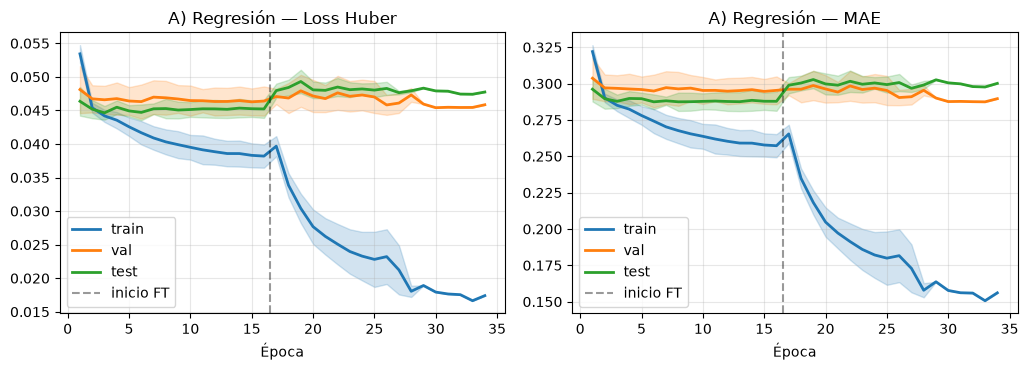

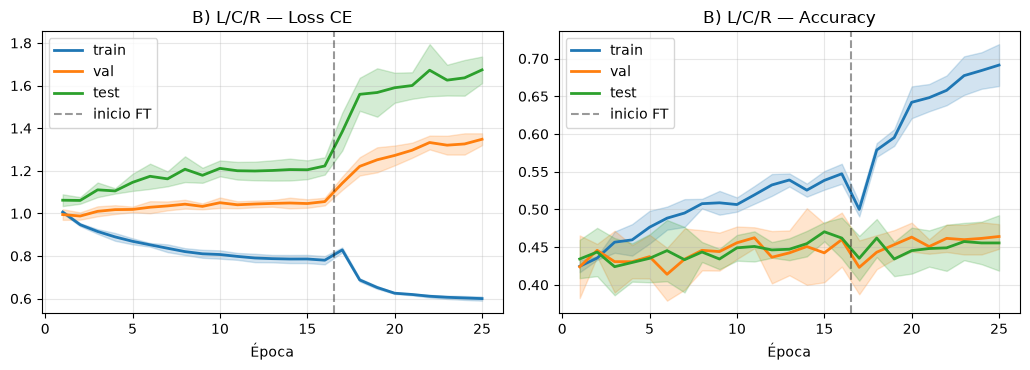

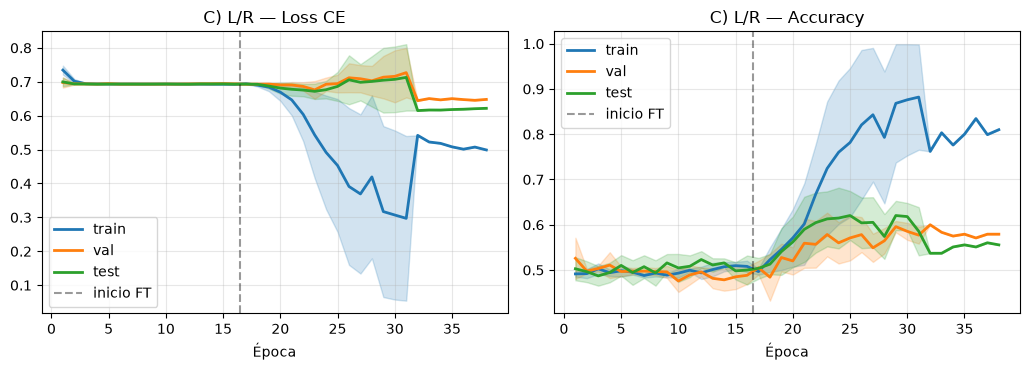

OOF Regresión (frames): {'mae': 0.2919, 'std_x': 0.0993}
OOF Reg -> lado (penales): 24.4%

OOF L/C/R (frames):
              precision    recall  f1-score   support

   izquierda       0.46      0.48      0.47       551
      centro       0.15      0.12      0.13       144
     derecha       0.44      0.45      0.44       503

    accuracy                           0.42      1198
   macro avg       0.35      0.35      0.35      1198
weighted avg       0.41      0.42      0.42      1198

OOF L/R (frames):
              precision    recall  f1-score   support

   izquierda       0.55      0.71      0.62       596
     derecha       0.59      0.42      0.49       602

    accuracy                           0.56      1198
   macro avg       0.57      0.56      0.55      1198
weighted avg       0.57      0.56      0.55      1198



In [9]:
plot_cv_curves(hist_reg, ['loss', 'mae'], ['Loss Huber', 'MAE'], 'A) Regresión')
plot_cv_curves(hist_lcr, ['loss', 'acc'], ['Loss CE', 'Accuracy'], 'B) L/C/R')
plot_cv_curves(hist_lr, ['loss', 'acc'], ['Loss CE', 'Accuracy'], 'C) L/R')

# OOF por penal
y_lcr_oof, pred_lcr_oof, gk_lcr_oof = preds_by_penal_from_proba(
    pid_dev, s_dev, oof_lcr, gk_lcr_dev)
y_lr_oof, pred_lr_oof, gk_lr_oof = preds_by_penal_from_proba(
    pid_dev, b_dev, oof_lr, gk_lr_dev)

order_d, idx_d = np.unique(pid_dev, return_index=True)
order_d = pid_dev[np.sort(idx_d)]
reg_side_oof = np.array([x_to_side(float(oof_xy[pid_dev == pid, 0].mean())) for pid in order_d])
y_side_oof = np.array([int(s_dev[pid_dev == pid][0]) for pid in order_d])

m_reg_oof = {
    'mae': float(np.mean(np.abs(oof_xy - y_dev))),
    'std_x': float(oof_xy[:, 0].std()),
    'side_acc_penal': float(np.mean(reg_side_oof == y_side_oof)),
}
print('OOF Regresión (frames):', {k: round(v, 4) for k, v in m_reg_oof.items() if k != 'side_acc_penal'})
print(f"OOF Reg -> lado (penales): {m_reg_oof['side_acc_penal']:.1%}")
print('\nOOF L/C/R (frames):')
print(classification_report(s_dev, np.argmax(oof_lcr, 1),
                            target_names=[SIDE_NAMES[i] for i in range(3)], zero_division=0))
print('OOF L/R (frames):')
print(classification_report(b_dev, np.argmax(oof_lr, 1),
                            target_names=[BINARY_NAMES[i] for i in range(2)], zero_division=0))



## 6. Análisis de los resultados OOF

Accuracy y McNemar OOF sobre `dev` (por penal).

In [12]:
acc_lcr_oof = float(np.mean(pred_lcr_oof == y_lcr_oof))
acc_lr_oof = float(np.mean(pred_lr_oof == y_lr_oof))
gk_lcr_acc_oof = float(np.mean(gk_lcr_oof == y_lcr_oof))
gk_lr_acc_oof = float(np.mean(gk_lr_oof == y_lr_oof))
maj_lcr = int(np.bincount(df_dev.drop_duplicates('penal_id')['side']).argmax())
maj_lr = int(np.bincount(df_dev.drop_duplicates('penal_id')['binary']).argmax())
maj_lcr_oof = float(np.mean(y_lcr_oof == maj_lcr))
maj_lr_oof = float(np.mean(y_lr_oof == maj_lr))

cmp_lcr_oof = compare_model_vs_arquero(
    y_lcr_oof, pred_lcr_oof, gk_lcr_oof, 'OOF B) L/C/R', plot=False)
cmp_lr_oof = compare_model_vs_arquero(
    y_lr_oof, pred_lr_oof, gk_lr_oof, 'OOF C) L/R', plot=False)

oof_tabla = pd.DataFrame([
    {
        'tarea': 'A) Reg→lado',
        'modelo': f"{m_reg_oof['side_acc_penal']:.1%}",
        'arquero': '-',
        'mayoritaria': '-',
        'Δ modelo-arquero': '-',
        'McNemar p': '-',
        'nota': f"std_x={m_reg_oof['std_x']:.3f}",
    },
    {
        'tarea': 'B) L/C/R',
        'modelo': f'{acc_lcr_oof:.1%}',
        'arquero': f'{gk_lcr_acc_oof:.1%}',
        'mayoritaria': f'{maj_lcr_oof:.1%}',
        'Δ modelo-arquero': f"{cmp_lcr_oof['acc_model'] - cmp_lcr_oof['acc_gk']:+.1%}",
        'McNemar p': f"{cmp_lcr_oof['mcnemar_p']:.4f}",
        'nota': '',
    },
    {
        'tarea': 'C) L/R',
        'modelo': f'{acc_lr_oof:.1%}',
        'arquero': f'{gk_lr_acc_oof:.1%}',
        'mayoritaria': f'{maj_lr_oof:.1%}',
        'Δ modelo-arquero': f"{cmp_lr_oof['acc_model'] - cmp_lr_oof['acc_gk']:+.1%}",
        'McNemar p': f"{cmp_lr_oof['mcnemar_p']:.4f}",
        'nota': '',
    },
])
print('OOF por penal (dev) - accuracy y McNemar:')
print(oof_tabla.to_string(index=False))



=== OOF B) L/C/R: modelo vs arquero (n=381 penales) ===
  Accuracy modelo:  43.6%  (166/381)
  Accuracy arquero: 43.6%  (166/381)
  Δ (modelo−arquero): +0.0%
  ambos OK=80 | solo modelo=86 | solo arquero=86 | ambos fail=129
  McNemar p=1.0000  (no significativo α=0.05)

=== OOF C) L/R: modelo vs arquero (n=381 penales) ===
  Accuracy modelo:  56.4%  (215/381)
  Accuracy arquero: 50.1%  (191/381)
  Δ (modelo−arquero): +6.3%
  ambos OK=112 | solo modelo=103 | solo arquero=79 | ambos fail=87
  McNemar p=0.0879  (no significativo α=0.05)
OOF por penal (dev) - accuracy y McNemar:
      tarea modelo arquero mayoritaria Δ modelo-arquero McNemar p        nota
A) Reg→lado  24.4%       -           -                -         - std_x=0.099
   B) L/C/R  43.6%   43.6%       47.0%            +0.0%    1.0000            
     C) L/R  56.4%   50.1%       50.9%            +6.3%    0.0879            


## 7. Análisis de los resultados finales

Ensemble: promedio de las predicciones de las 5 redes sobre el test hold-out.

**Clasificación (B y C).** Accuracy en barras y McNemar vs arquero en dos granularidades:
- *por frame*: cada crop de test cuenta por separado;
- *por penal*: promediamos las probs de los frames del mismo `penal_id` y decidimos una sola vez (comparable al arquero por tiro).

**Regresión (A).** También usamos promediaje: promedio de `(x,y)` predichos por `penal_id` para el scatter y Reg→lado por penal. A nivel frame reportamos MAE / `std_x` sobre todos los crops.


=== A) Regresión (ensemble) ===
  frames: MAE=0.290  std_x=0.079  Reg→lado=31.5%
  penales (promedio de frames): Reg→lado=27.9%


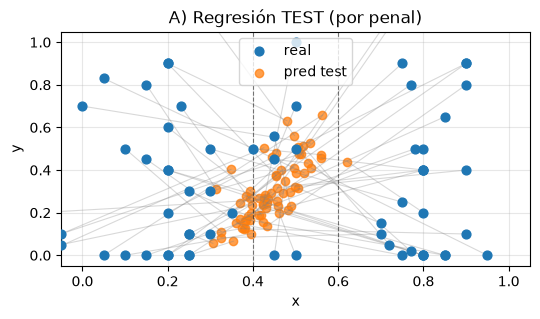

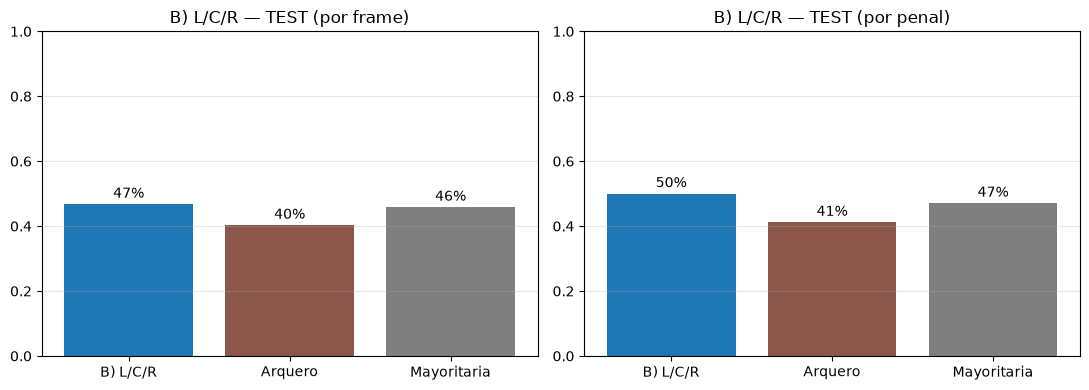


=== B) L/C/R McNemar ===

=== TEST B) L/C/R (por frame): modelo vs arquero (n=216 penales) ===
  Accuracy modelo:  46.8%  (101/216)
  Accuracy arquero: 40.3%  (87/216)
  Δ (modelo−arquero): +6.5%
  ambos OK=49 | solo modelo=52 | solo arquero=38 | ambos fail=77
  McNemar p=0.1702  (no significativo α=0.05)


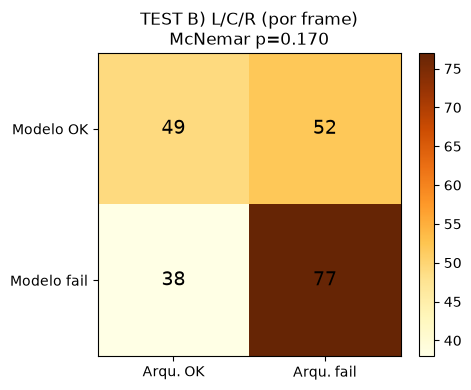


=== TEST B) L/C/R (por penal): modelo vs arquero (n=68 penales) ===
  Accuracy modelo:  50.0%  (34/68)
  Accuracy arquero: 41.2%  (28/68)
  Δ (modelo−arquero): +8.8%
  ambos OK=20 | solo modelo=14 | solo arquero=8 | ambos fail=26
  McNemar p=0.2863  (no significativo α=0.05)


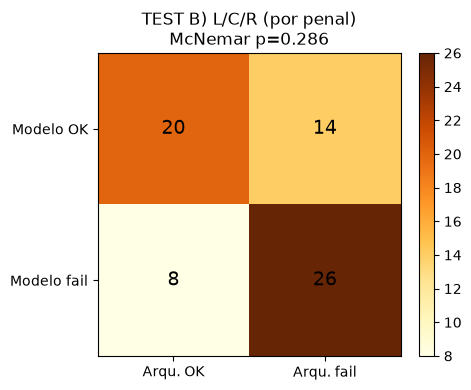

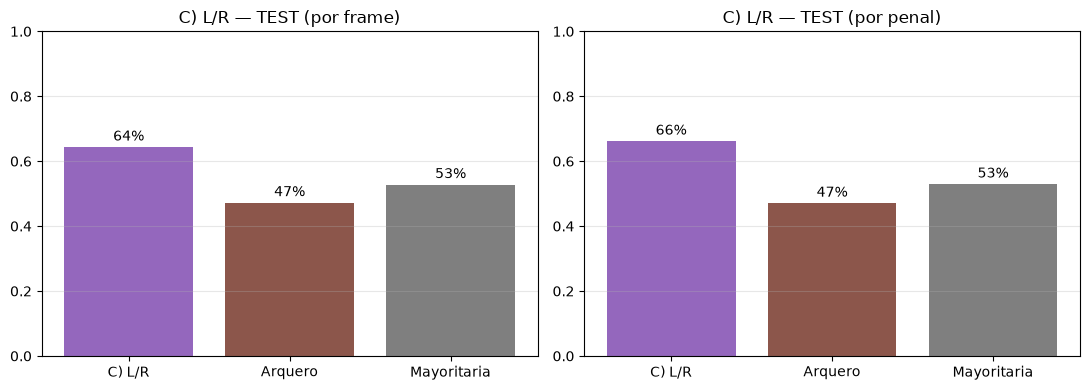


=== C) L/R McNemar ===

=== TEST C) L/R (por frame): modelo vs arquero (n=216 penales) ===
  Accuracy modelo:  64.4%  (139/216)
  Accuracy arquero: 47.2%  (102/216)
  Δ (modelo−arquero): +17.1%
  ambos OK=71 | solo modelo=68 | solo arquero=31 | ambos fail=46
  McNemar p=0.0003  (significativo α=0.05)


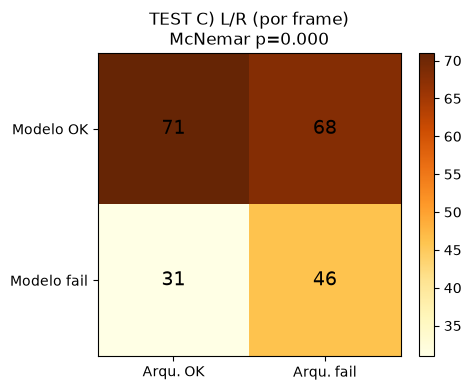


=== TEST C) L/R (por penal): modelo vs arquero (n=68 penales) ===
  Accuracy modelo:  66.2%  (45/68)
  Accuracy arquero: 47.1%  (32/68)
  Δ (modelo−arquero): +19.1%
  ambos OK=21 | solo modelo=24 | solo arquero=11 | ambos fail=12
  McNemar p=0.0410  (significativo α=0.05)


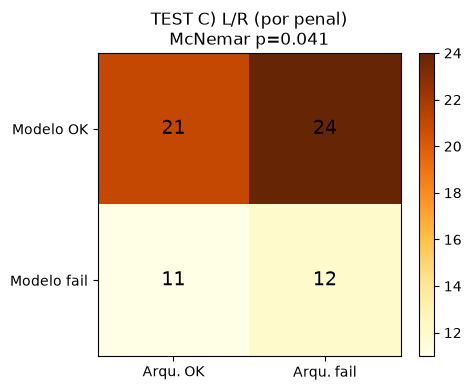


RESUMEN TEST
A) Regresión: MAE_frame=0.290  std_x=0.079  →lado frame=31.5%  →lado penal=27.9%
B) L/C/R: frame=46.8% (gk 40.3%) | penal=50.0% (gk 41.2%) | McNemar p frame=0.1702 penal=0.2863
C) L/R:   frame=64.4% (gk 47.2%) | penal=66.2% (gk 47.1%) | McNemar p frame=0.0003 penal=0.0410


In [13]:
y_lcr_te, pred_lcr_te, gk_lcr_p = preds_by_penal_from_proba(pid_te, s_te, test_lcr, gk_lcr_te)
y_lr_te, pred_lr_te, gk_lr_p = preds_by_penal_from_proba(pid_te, b_te, test_lr, gk_lr_te)

order_t, idx_t = np.unique(pid_te, return_index=True)
order_t = pid_te[np.sort(idx_t)]
xy_penal_true_te = np.array([y_te[pid_te == pid].mean(axis=0) for pid in order_t])
xy_penal_pred_te = np.array([test_xy[pid_te == pid].mean(axis=0) for pid in order_t])
reg_side_te = np.array([x_to_side(float(p[0])) for p in xy_penal_pred_te])
y_side_te = np.array([int(s_te[pid_te == pid][0]) for pid in order_t])
m_reg_te_side = float(np.mean(reg_side_te == y_side_te))
m_reg_te = {
    'mae': float(np.mean(np.abs(test_xy - y_te))),
    'std_x': float(test_xy[:, 0].std()),
}

# Predicciones / labels por FRAME (todos los crops de test)
pred_lcr_fr = np.argmax(test_lcr, axis=1)
pred_lr_fr = np.argmax(test_lr, axis=1)
reg_side_fr = np.array([x_to_side(float(x)) for x in test_xy[:, 0]])
acc_reg_fr = float(np.mean(reg_side_fr == s_te))
acc_lcr_fr = float(np.mean(pred_lcr_fr == s_te))
acc_lr_fr = float(np.mean(pred_lr_fr == b_te))
gk_lcr_acc_fr = float(np.mean(gk_lcr_te == s_te))
gk_lr_acc_fr = float(np.mean(gk_lr_te == b_te))
maj_lcr_fr = float(np.mean(s_te == maj_lcr))
maj_lr_fr = float(np.mean(b_te == maj_lr))

# Accuracy por PENAL (ya agregados)
acc_lcr_te = float(np.mean(pred_lcr_te == y_lcr_te))
acc_lr_te = float(np.mean(pred_lr_te == y_lr_te))
gk_lcr_acc_te = float(np.mean(gk_lcr_p == y_lcr_te))
gk_lr_acc_te = float(np.mean(gk_lr_p == y_lr_te))
maj_lcr_te = float(np.mean(y_lcr_te == maj_lcr))
maj_lr_te = float(np.mean(y_lr_te == maj_lr))

print('=== A) Regresión (ensemble) ===')
print(f"  frames: MAE={m_reg_te['mae']:.3f}  std_x={m_reg_te['std_x']:.3f}  Reg→lado={acc_reg_fr:.1%}")
print(f"  penales (promedio de frames): Reg→lado={m_reg_te_side:.1%}")

# Scatter regresión TEST por penal (coords promediadas)
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(xy_penal_true_te[:, 0], xy_penal_true_te[:, 1], c='tab:blue', s=40, label='real', zorder=3)
ax.scatter(xy_penal_pred_te[:, 0], xy_penal_pred_te[:, 1], c='tab:orange', s=36, label='pred test', alpha=0.75)
for a, b in zip(xy_penal_true_te, xy_penal_pred_te):
    ax.plot([a[0], b[0]], [a[1], b[1]], color='gray', alpha=0.3, lw=0.8)
ax.axvline(0.4, color='k', ls='--', lw=0.8, alpha=0.5)
ax.axvline(0.6, color='k', ls='--', lw=0.8, alpha=0.5)
ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
ax.set_aspect(0.5, adjustable='box')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_title('A) Regresión TEST (por penal)')
ax.legend(); ax.grid(True, alpha=0.3)
fig.tight_layout(); plt.show()


def _bars_clf(ax, labels, vals, colors, title):
    ax.bar(labels, vals, color=colors)
    ax.set_ylim(0, 1)
    ax.set_title(title)
    ax.grid(True, axis='y', alpha=0.3)
    for i, v in enumerate(vals):
        ax.text(i, v + 0.02, f'{v:.0%}', ha='center')


# ---- B) L/C/R: barras frame + penal ----
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
_bars_clf(axes[0],
          ['B) L/C/R', 'Arquero', 'Mayoritaria'],
          [acc_lcr_fr, gk_lcr_acc_fr, maj_lcr_fr],
          ['tab:blue', 'tab:brown', 'tab:gray'],
          'B) L/C/R — TEST (por frame)')
_bars_clf(axes[1],
          ['B) L/C/R', 'Arquero', 'Mayoritaria'],
          [acc_lcr_te, gk_lcr_acc_te, maj_lcr_te],
          ['tab:blue', 'tab:brown', 'tab:gray'],
          'B) L/C/R — TEST (por penal)')
fig.tight_layout(); plt.show()

print('\n=== B) L/C/R McNemar ===')
cmp_lcr_fr = compare_model_vs_arquero(s_te, pred_lcr_fr, gk_lcr_te, 'TEST B) L/C/R (por frame)', plot=True)
cmp_lcr_te = compare_model_vs_arquero(y_lcr_te, pred_lcr_te, gk_lcr_p, 'TEST B) L/C/R (por penal)', plot=True)

# ---- C) L/R: barras frame + penal ----
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
_bars_clf(axes[0],
          ['C) L/R', 'Arquero', 'Mayoritaria'],
          [acc_lr_fr, gk_lr_acc_fr, maj_lr_fr],
          ['tab:purple', 'tab:brown', 'tab:gray'],
          'C) L/R — TEST (por frame)')
_bars_clf(axes[1],
          ['C) L/R', 'Arquero', 'Mayoritaria'],
          [acc_lr_te, gk_lr_acc_te, maj_lr_te],
          ['tab:purple', 'tab:brown', 'tab:gray'],
          'C) L/R — TEST (por penal)')
fig.tight_layout(); plt.show()

print('\n=== C) L/R McNemar ===')
cmp_lr_fr = compare_model_vs_arquero(b_te, pred_lr_fr, gk_lr_te, 'TEST C) L/R (por frame)', plot=True)
cmp_lr_te = compare_model_vs_arquero(y_lr_te, pred_lr_te, gk_lr_p, 'TEST C) L/R (por penal)', plot=True)

print('\nRESUMEN TEST')
print(f"A) Regresión: MAE_frame={m_reg_te['mae']:.3f}  std_x={m_reg_te['std_x']:.3f}  "
      f"→lado frame={acc_reg_fr:.1%}  →lado penal={m_reg_te_side:.1%}")
print(f"B) L/C/R: frame={acc_lcr_fr:.1%} (gk {gk_lcr_acc_fr:.1%}) | "
      f"penal={acc_lcr_te:.1%} (gk {gk_lcr_acc_te:.1%}) | McNemar p frame={cmp_lcr_fr['mcnemar_p']:.4f} penal={cmp_lcr_te['mcnemar_p']:.4f}")
print(f"C) L/R:   frame={acc_lr_fr:.1%} (gk {gk_lr_acc_fr:.1%}) | "
      f"penal={acc_lr_te:.1%} (gk {gk_lr_acc_te:.1%}) | McNemar p frame={cmp_lr_fr['mcnemar_p']:.4f} penal={cmp_lr_te['mcnemar_p']:.4f}")
